In [ ]:
import random, optuna

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, f1_score, accuracy_score, make_scorer, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import StandardScaler

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from imblearn.over_sampling import SMOTE
from scipy.stats import loguniform

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import Callback

import keras_tuner as kt
from keras_tuner.tuners import BayesianOptimization

from ray.tune.schedulers import ASHAScheduler
from ray import tune, train

from keras_visualizer import visualizer
from IPython.display import Image

# 1. Изучение примеров

Перед выполнением лабораторной работы были изучены представленные примеры

# 2. Загрузка и подготовка данных

In [2]:
data_regr = pd.read_csv(r'D:\Python\OmGTU\ML\data\regr_opt.csv')
X_regr = data_regr.drop(columns=['price'])
y_regr = data_regr['price']

X_regr_train, X_regr_test, y_regr_train, y_regr_test = train_test_split(X_regr, y_regr, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_regr_train = scaler.fit_transform(X_regr_train)
X_regr_test = scaler.transform(X_regr_test)

X_regr_train.shape, X_regr_test.shape, y_regr_train.shape, y_regr_test.shape

((43035, 4), (10759, 4), (43035,), (10759,))

In [3]:
def test_regr(model, X, y, solver: str, epochs: int, is_keras: bool = False):
    metrics = {
        'model': model.__class__.__name__,
        'optim': solver,
        'epochs': epochs,
        'train_R²': [], 'train_MSE': [], 'train_RMSE': [], 'train_MAE': [],
        'test_R²': [], 'test_MSE': [], 'test_RMSE': [], 'test_MAE': []
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.values[train_idx], X.values[test_idx]
        y_train, y_test = y.values[train_idx], y.values[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if is_keras:
            model.fit(X_train_scaled, y_train, epochs=epochs, verbose=1)
            y_train_pred = model.predict(X_train_scaled, verbose=0).reshape(-1)
            y_test_pred = model.predict(X_test_scaled, verbose=0).reshape(-1)
        else:
            model.fit(X_train_scaled, y_train)
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)

        metrics['train_R²'].append(round(r2_score(y_train, y_train_pred), 2))
        metrics['train_MSE'].append(round(mean_squared_error(y_train, y_train_pred), 4))
        metrics['train_RMSE'].append(round(np.sqrt(mean_squared_error(y_train, y_train_pred)), 4))
        metrics['train_MAE'].append(round(mean_absolute_error(y_train, y_train_pred), 4))

        metrics['test_R²'].append(round(r2_score(y_test, y_test_pred), 2))
        metrics['test_MSE'].append(round(mean_squared_error(y_test, y_test_pred), 4))
        metrics['test_RMSE'].append(round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 4))
        metrics['test_MAE'].append(round(mean_absolute_error(y_test, y_test_pred), 4))

    result = {k: np.mean(v) if isinstance(v, list) else v for k, v in metrics.items()}
    return pd.Series(result)

In [4]:
data_clas = pd.read_csv(r'D:\Python\OmGTU\ML\data\clas_opt.csv')
X_clas = data_clas.drop(columns=['fraud'])
y_clas = data_clas['fraud']

X_clas_train, X_clas_test, y_clas_train, y_clas_test = train_test_split(X_clas, y_clas, test_size=0.2, stratify=y_clas, random_state=42)
scaler = StandardScaler()
X_clas_train = scaler.fit_transform(X_clas_train)
X_clas_test = scaler.transform(X_clas_test)
X_clas_train, y_clas_train = SMOTE(random_state=42).fit_resample(X_clas_train, y_clas_train)

X_clas_train.shape, X_clas_test.shape, y_clas_train.shape, y_clas_test.shape

((58406, 3), (8000, 3), (58406,), (8000,))

In [5]:
def test_clas(model, X, y, solver, epochs, is_keras=False):
    metrics = {
        'model': model.__class__.__name__,
        'optim': solver,
        'epochs': epochs,
        'train_f1-score': [], 'train_accuracy': [],
        'test_f1-score': [], 'test_accuracy': []
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.values[train_idx], X.values[test_idx]
        y_train, y_test = y.values[train_idx], y.values[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        smote = SMOTE(random_state=42)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

        if is_keras:
            model.fit(X_train_bal, y_train_bal, epochs=epochs, verbose=1)

            y_train_pred_prob = model.predict(X_train_bal, verbose=0)
            y_test_pred_prob = model.predict(X_test_scaled, verbose=0)

            y_train_pred = (y_train_pred_prob > 0.5).astype("int32")
            y_test_pred = (y_test_pred_prob > 0.5).astype("int32")
        else:
            model.fit(X_train_bal, y_train_bal)
            y_train_pred = model.predict(X_train_bal)
            y_test_pred = model.predict(X_test_scaled)

        metrics['train_f1-score'].append(round(f1_score(y_train_bal, y_train_pred, average='weighted'), 2))
        metrics['train_accuracy'].append(round(accuracy_score(y_train_bal, y_train_pred), 2))

        metrics['test_f1-score'].append(round(f1_score(y_test, y_test_pred, average='weighted'), 2))
        metrics['test_accuracy'].append(round(accuracy_score(y_test, y_test_pred), 2))

    result = {k: np.mean(v) if isinstance(v, list) else v for k, v in metrics.items()}
    return pd.Series(result)

# 3. Решение задачи регрессии и классификации с помощью FCNN

## Regression_sklearn

### Optuna

In [ ]:
def objective_optuna(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [
            '(50,)', '(75,)', '(100,)', '(150,)', '(200,)',
            '(50,30)', '(100,50)', '(150,75)', '(200,100)'
        ]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),
        'alpha': trial.suggest_float('alpha',
                                    low=0.000085,
                                    high=0.008519,
                                    log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init',
                                                low=0.000097,
                                                high=0.009725,
                                                log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        'max_iter': trial.suggest_int('max_iter', 150, 600),
        'early_stopping': True,
        'n_iter_no_change': trial.suggest_int('n_iter_no_change', 5, 20)
    }

    params['hidden_layer_sizes'] = eval(params['hidden_layer_sizes'])

    model = MLPRegressor(**params, random_state=42)

    model.fit(X_regr_train, y_regr_train)
    y_pred = model.predict(X_regr_test)

    return root_mean_squared_error(y_regr_test, y_pred)


study = optuna.create_study(direction='minimize')
study.optimize(objective_optuna, n_trials=50, show_progress_bar=True, n_jobs=-1)

print("Best Optuna RMSE:", study.best_value)
print("Best Optuna params:", study.best_params)

[I 2025-05-26 13:45:43,163] A new study created in memory with name: no-name-612d4b53-f01d-41b9-ae02-35ea6e51cd9c


  0%|          | 0/50 [00:00<?, ?it/s]

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_base.py:172: RuntimeWarning: overflow encountered in square
  return ((y_true - y_pred) ** 2).mean() / 2
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\utils\extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[I 2025-05-26 13:46:44,477] Trial 4 finished with value: 891.925051781792 and parameters: {'hidden_layer_sizes': '(150,)', 'activation': 'tanh', 'solver': 'sgd', 'alpha': 0.000446458116253335, 'learning_rate_init': 0.001551815374378621, 'batch_size': 256, 'max_iter': 410, 'n_iter_no_change': 15}. Best is trial 4 with value: 891.925051781792.


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


...

[I 2025-05-26 15:03:33,163] Trial 45 finished with value: 727.4242868587289 and parameters: {'hidden_layer_sizes': '(200,)', 'activation': 'relu', 'solver': 'adam', 'alpha': 0.001775179794343103, 'learning_rate_init': 0.00034430578832338573, 'batch_size': 128, 'max_iter': 552, 'n_iter_no_change': 12}. Best is trial 23 with value: 527.3703233837109.


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (555) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2025-05-26 15:03:37,631] Trial 46 finished with value: 731.4213763162583 and parameters: {'hidden_layer_sizes': '(200,)', 'activation': 'relu', 'solver': 'adam', 'alpha': 0.0017245554353846272, 'learning_rate_init': 0.00032276953518310854, 'batch_size': 128, 'max_iter': 555, 'n_iter_no_change': 12}. Best is trial 23 with value: 527.3703233837109.


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (554) reached and the optimization hasn't converged yet.
  warnings.warn(
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (535) reached and the optimization hasn't converged yet.
  warnings.warn(


[I 2025-05-26 15:03:57,009] Trial 49 finished with value: 5507.917894190026 and parameters: {'hidden_layer_sizes': '(200,)', 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.0016942808620516588, 'learning_rate_init': 0.00019903211145648418, 'batch_size': 128, 'max_iter': 554, 'n_iter_no_change': 13}. Best is trial 23 with value: 527.3703233837109.
[I 2025-05-26 15:03:57,106] Trial 48 finished with value: 731.1370734353118 and parameters: {'hidden_layer_sizes': '(200,)', 'activation': 'relu', 'solver': 'adam', 'alpha': 0.0016826603300801471, 'learning_rate_init': 0.0003547008905715923, 'batch_size': 128, 'max_iter': 535, 'n_iter_no_change': 13}. Best is trial 23 with value: 527.3703233837109.
[I 2025-05-26 15:04:38,764] Trial 42 finished with value: 578.7123821781164 and parameters: {'hidden_layer_sizes': '(150,75)', 'activation': 'relu', 'solver': 'adam', 'alpha': 0.00025336492995392095, 'learning_rate_init': 0.0003684767675891651, 'batch_size': 128, 'max_iter': 543, 'n_iter_no_change

In [ ]:
# Best Optuna RMSE: 527.3703233837109
best_optuna = {'hidden_layer_sizes': (150,75), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.001196702696826896, 'learning_rate_init': 0.009441580172188557, 'batch_size': 32, 'max_iter': 600, 'n_iter_no_change': 5}

### RandomizedSearchCV

In [ ]:
param_dist = {
    'hidden_layer_sizes': [(50,), (75,), (100,), (150,), (200,),
                          (50,30), (100,50), (150,75), (200,100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': loguniform(8.5e-5, 8.5e-3),
    'learning_rate_init': loguniform(9.7e-5, 9.7e-3),
    'batch_size': [32, 64, 128, 256],
    'max_iter': np.arange(150, 601),
    'early_stopping': [True],
    'n_iter_no_change': np.arange(5, 21)
}

mlp = MLPRegressor(random_state=42)

random_search = RandomizedSearchCV(estimator=mlp, param_distributions=param_dist, n_iter=50,
                                   scoring='neg_root_mean_squared_error', cv=2, verbose=2,
                                   random_state=42, n_jobs=-1)

random_search.fit(X_regr_train, y_regr_train)

print("Best RMSE:", -random_search.best_score_)
print("Best params:", random_search.best_params_)

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Best RMSE: 568.0375073860112
Best params: {'activation': 'relu', 'alpha': 0.0002428226815370111, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': 0.004195669455125621, 'max_iter': 382, 'n_iter_no_change': 7, 'solver': 'lbfgs'}


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
# Best RandomizedSearchCV RMSE: 568.0375073860112
best_rscv = {'activation': 'relu', 'alpha': 0.0002428226815370111, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': 0.004195669455125621, 'max_iter': 382, 'n_iter_no_change': 7, 'solver': 'lbfgs'}

### Hyperopt

In [ ]:
class RandomStateWrapper:
    def __init__(self, seed):
        self.seed = seed
        self.rng = random.Random(seed)

    def integers(self, max_val):
        return self.rng.randint(0, max_val)

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', [
        (50,), (75,), (100,), (150,), (200,),
        (50,30), (100,50), (150,75), (200,100)
    ]),
    'activation': hp.choice('activation', ['relu', 'tanh', 'logistic']),
    'solver': hp.choice('solver', ['adam', 'sgd', 'lbfgs']),
    'alpha': hp.loguniform('alpha', np.log(8.5e-5), np.log(8.5e-3)),
    'learning_rate_init': hp.loguniform('learning_rate_init', np.log(9.7e-5), np.log(9.7e-3)),
    'batch_size': hp.choice('batch_size', [32, 64, 128, 256]),
    'max_iter': hp.choice('max_iter', list(range(150, 601))),
    'early_stopping': True,
    'n_iter_no_change': hp.choice('n_iter_no_change', list(range(5, 21)))
}

def objective(params):
    try:
        model = MLPRegressor(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            activation=params['activation'],
            solver=params['solver'],
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            batch_size=params['batch_size'],
            max_iter=params['max_iter'],
            early_stopping=params['early_stopping'],
            n_iter_no_change=params['n_iter_no_change'],
            random_state=42
        )

        scores = cross_val_score(
            model,
            X_regr_train,
            y_regr_train,
            cv=3,
            scoring=make_scorer(root_mean_squared_error),
            n_jobs=-1
        )

        return {'loss': np.mean(scores), 'status': STATUS_OK}

    except Exception as e:
        print(f"Ошибка: {e}")
        return {'loss': np.inf, 'status': STATUS_OK}


trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=RandomStateWrapper(42),
    verbose=True
)

print("\nЛучшие параметры:")
best_params = {
    'hidden_layer_sizes': [(50,), (75,), (100,), (150,), (200,),
                            (50,30), (100,50), (150,75), (200,100)][best['hidden_layer_sizes']],
    'activation': ['relu', 'tanh', 'logistic'][best['activation']],
    'solver': ['adam', 'sgd', 'lbfgs'][best['solver']],
    'alpha': best['alpha'],
    'learning_rate_init': best['learning_rate_init'],
    'batch_size': [32, 64, 128, 256][best['batch_size']],
    'max_iter': best['max_iter'],
    'early_stopping': True,
    'n_iter_no_change': best['n_iter_no_change']
}

print(best_params)

best_model = MLPRegressor(**best_params, random_state=42)
best_model.fit(X_regr_train, y_regr_train)
y_pred = best_model.predict(X_regr_test)
rmse = root_mean_squared_error(y_regr_test, y_pred)
print(f"\nRMSE на тесте: {rmse:.4f}")

100%|██████████| 50/50 [1:35:04<00:00, 114.09s/trial, best loss: 562.8123725773902]

Лучшие параметры:
{'hidden_layer_sizes': (150, 75), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.00015722007026987224, 'learning_rate_init': 0.00036054054758752883, 'batch_size': 128, 'max_iter': 416, 'early_stopping': True, 'n_iter_no_change': 8}

RMSE на тесте: 538.2114


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
# Best Hyperopt RMSE: 538.2114
best_hyperopt = {'hidden_layer_sizes': (150, 75), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.00015722007026987224, 'learning_rate_init': 0.00036054054758752883, 'batch_size': 128, 'max_iter': 416, 'early_stopping': True, 'n_iter_no_change': 8}

### Выбор лучшей модели

In [18]:
# optuna
model = MLPRegressor(**{'hidden_layer_sizes': (150,75), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.001196702696826896, 'learning_rate_init': 0.009441580172188557, 'batch_size': 32, 'max_iter': 200, 'n_iter_no_change': 5})
test_regr(model, X_regr, y_regr, 'lbfgs', 200)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

model         MLPRegressor
optim                lbfgs
epochs                 200
train_R²          0.979128
train_MSE    331953.113486
train_MAE       315.924918
test_R²           0.978496
test_MSE     342133.215442
test_MAE        318.067893
dtype: object

In [19]:
# randomizedsearchcv
model = MLPRegressor(**{'activation': 'relu', 'alpha': 0.0002428226815370111, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': 0.004195669455125621, 'max_iter': 200, 'n_iter_no_change': 7, 'solver': 'lbfgs'})
test_regr(model, X_regr, y_regr, 'lbfgs', 200)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

model         MLPRegressor
optim                lbfgs
epochs                 200
train_R²          0.979675
train_MSE    323241.663096
train_MAE       310.432933
test_R²           0.979078
test_MSE     332866.422564
test_MAE        312.454239
dtype: object

In [20]:
# hyperopt
model = MLPRegressor(**{'hidden_layer_sizes': (150, 75), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.00015722007026987224, 'learning_rate_init': 0.00036054054758752883, 'batch_size': 128, 'max_iter': 200, 'early_stopping': True, 'n_iter_no_change': 8})
test_regr(model, X_regr, y_regr, 'lbfgs', 200)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

model         MLPRegressor
optim                lbfgs
epochs                 200
train_R²          0.979573
train_MSE    324895.585984
train_MAE       311.992636
test_R²            0.97904
test_MSE     333361.410889
test_MAE        314.427662
dtype: object

Самая точная модель оказалась модель с гиперпараметрами, подобранными с помощью **RandomizedSearchCV** (определено по _MSE_ и _R²_)

## Regression_tensorflow+keras

### Optuna

In [8]:
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def build_model(trial):
    model = keras.Sequential()

    n_layers = trial.suggest_int("n_layers", 1, 2)
    for i in range(n_layers):
        model.add(
            layers.Dense(
                units=trial.suggest_int(f"units_{i}", 50, 200, step=25),
                activation=trial.suggest_categorical("activation", ['relu', 'tanh']),
            )
        )

    model.add(layers.Dense(1))

    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd", "rmsprop"])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    if optimizer_name == "adam":
        beta_1 = trial.suggest_float("adam_beta_1", 0.8, 0.999)
        beta_2 = trial.suggest_float("adam_beta_2", 0.9, 0.9999)
        optimizer = keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=beta_1,
            beta_2=beta_2
        )
    elif optimizer_name == "sgd":
        momentum = trial.suggest_float("sgd_momentum", 0.0, 0.9)
        nesterov = trial.suggest_categorical("sgd_nesterov", [False, True])
        optimizer = keras.optimizers.SGD(
            learning_rate=lr,
            momentum=momentum,
            nesterov=nesterov
        )
    else:
        rho = trial.suggest_float("rmsprop_rho", 0.8, 0.999)
        momentum = trial.suggest_float("rmsprop_momentum", 0.0, 0.9)
        optimizer = keras.optimizers.RMSprop(
            learning_rate=lr,
            rho=rho,
            momentum=momentum
        )

    model.compile(optimizer=optimizer, loss=root_mean_squared_error)
    return model

def objective(trial):
    model = build_model(trial)

    history = model.fit(
        X_regr_train, y_regr_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_regr_test, y_regr_test),
        verbose=0,
    )

    return history.history["val_loss"][-1]

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, n_jobs=-1)

print("Best trial:")
trial = study.best_trial
print(f"  Best RMSE: {trial.value:.4f}")
print("  Best params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-05-28 14:57:09,468] A new study created in memory with name: no-name-9c64553b-52ac-4122-9b8f-5e46851e507a
[I 2025-05-28 15:07:28,635] Trial 4 finished with value: 678.3710327148438 and parameters: {'n_layers': 1, 'units_0': 200, 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.0008183272265189873, 'adam_beta_1': 0.885174291704838, 'adam_beta_2': 0.9193887740316387}. Best is trial 4 with value: 678.3710327148438.
[I 2025-05-28 15:07:36,012] Trial 5 finished with value: 537.5198974609375 and parameters: {'n_layers': 2, 'units_0': 50, 'activation': 'tanh', 'units_1': 175, 'optimizer': 'rmsprop', 'lr': 0.005521577153900797, 'rmsprop_rho': 0.8463580309415889, 'rmsprop_momentum': 0.5263692425887838}. Best is trial 5 with value: 537.5198974609375.
[I 2025-05-28 15:07:39,204] Trial 6 finished with value: 782.7044067382812 and parameters: {'n_layers': 1, 'units_0': 150, 'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.00039518700871418554, 'sgd_momentum': 0.3344452949773875, 'sgd_nes

Best trial:
  Best RMSE: 511.4855
  Best params:
    n_layers: 2
    units_0: 150
    activation: relu
    units_1: 150
    optimizer: rmsprop
    lr: 0.006761133009191603
    rmsprop_rho: 0.8797626552850855
    rmsprop_momentum: 0.21112666617269985


In [ ]:
# Best Optuna RMSE: 511.4855
best_optuna = {'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 150, 'optimizer': 'rmsprop', 'lr': 0.006761133009191603, 'rmsprop_rho': 0.8797626552850855, 'rmsprop_momentum': 0.21112666617269985}

### KerasTuner

In [ ]:
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def build_model(hp):
    model = keras.Sequential()

    n_layers = hp.Int('n_layers', 1, 2)
    for i in range(n_layers):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', 50, 200, step=25),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))
    
    model.add(layers.Dense(1))
    
    # Подбор оптимизатора
    optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    lr = hp.Float('lr', 1e-4, 1e-2, sampling='log')
    
    if optimizer_name == 'adam':
        optimizer = keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=hp.Float('adam_beta_1', 0.8, 0.999),
            beta_2=hp.Float('adam_beta_2', 0.9, 0.9999)
        )
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.SGD(
            learning_rate=lr,
            momentum=hp.Float('sgd_momentum', 0.0, 0.9),
            nesterov=hp.Boolean('sgd_nesterov')
        )
    else:
        optimizer = keras.optimizers.RMSprop(
            learning_rate=lr,
            rho=hp.Float('rmsprop_rho', 0.8, 0.999),
            momentum=hp.Float('rmsprop_momentum', 0.0, 0.9)
        )
    
    model.compile(optimizer=optimizer, loss=root_mean_squared_error)
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=50,
    directory='keras_tuner',
    project_name='regression'
)

tuner.search(
    X_regr_train, y_regr_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_regr_test, y_regr_test),
    verbose=1
)

best_model = tuner.get_best_models()[0]
best_hps = tuner.get_best_hyperparameters()[0]

print("Best hyperparameters:")
print(best_hps.values)

test_loss = best_model.evaluate(X_regr_test, y_regr_test)
print(f"\nTest RMSE: {test_loss:.4f}")

Trial 50 Complete [00h 02m 10s]
val_loss: 538.11572265625

Best val_loss So Far: 518.7451171875
Total elapsed time: 01h 38m 58s
Best hyperparameters:
{'n_layers': 2, 'units_0': 175, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.005039274952483862, 'adam_beta_1': 0.8542987494292626, 'adam_beta_2': 0.9344736642511476, 'units_1': 100, 'sgd_momentum': 0.03678497232572311, 'sgd_nesterov': False, 'rmsprop_rho': 0.8991159779021353, 'rmsprop_momentum': 0.4755943731202676}
  1/337 ━━━━━━━━━━━━━━━━━━━━ 35s 106ms/step - loss: 460.6516

d:\Python\OmGTU\venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 530.2220

Test RMSE: 518.7451


In [ ]:
# Best KerasTuner RMSE: 518.7451
best_keras = {'n_layers': 2, 'units_0': 175, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.005039274952483862, 'adam_beta_1': 0.8542987494292626, 'adam_beta_2': 0.9344736642511476, 'units_1': 100, 'sgd_momentum': 0.03678497232572311, 'sgd_nesterov': False, 'rmsprop_rho': 0.8991159779021353, 'rmsprop_momentum': 0.4755943731202676}

### RayTune

In [ ]:
def short_trial_name(trial):
    return f"trial_{trial.trial_id}"

class TuneReporterCallback(Callback):
    def __init__(self, reporter=None, freq="epoch", validation_data=None):
        self.reporter = reporter
        self.freq = freq
        self.validation_data = validation_data
    
    def on_epoch_end(self, epoch, logs=None):
        if self.freq == "epoch" and self.reporter is not None:
            self.reporter(logs)

    def on_train_end(self, logs=None):
        if self.freq == "train_end" and self.reporter is not None and self.validation_data is not None:
            X_val, y_val = self.validation_data
            predictions = self.model.predict(X_val)
            rmse = np.sqrt(np.mean((predictions.ravel() - y_val) ** 2))
            self.reporter({"rmse": rmse})

def train_regression(config):
    model = keras.Sequential()

    for i in range(config['n_layers']):
        units = config[f'units_{i}']
        model.add(layers.Dense(units=units, activation=config['activation']))
    
    model.add(layers.Dense(1))

    if config['optimizer'] == 'adam':
        optimizer = keras.optimizers.Adam(
            learning_rate=config['lr'],
            beta_1=config['adam_beta_1'],
            beta_2=config['adam_beta_2']
        )
    elif config['optimizer'] == 'sgd':
        optimizer = keras.optimizers.SGD(
            learning_rate=config['lr'],
            momentum=config['sgd_momentum'],
            nesterov=config['sgd_nesterov']
        )
    else:
        optimizer = keras.optimizers.RMSprop(
            learning_rate=config['lr'],
            rho=config['rmsprop_rho'],
            momentum=config['rmsprop_momentum']
        )
    
    model.compile(optimizer=optimizer, loss='mse')

    model.fit(
        X_regr_train, y_regr_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_regr_test, y_regr_test),
        verbose=0,
        callbacks=[TuneReporterCallback(reporter=train.report, freq="train_end", validation_data=(X_regr_test, y_regr_test))]
    )

config = {
    'n_layers': tune.choice([1, 2]),
    'units_0': tune.choice([50, 75, 100, 125, 150, 175, 200]),
    'units_1': tune.choice([50, 75, 100, 125, 150, 175, 200]),
    'activation': tune.choice(['relu', 'tanh']),
    'optimizer': tune.choice(['adam', 'sgd', 'rmsprop']),
    'lr': tune.loguniform(1e-4, 1e-2),
    'adam_beta_1': tune.uniform(0.8, 0.999),
    'adam_beta_2': tune.uniform(0.9, 0.9999),
    'sgd_momentum': tune.uniform(0.0, 0.9),
    'sgd_nesterov': tune.choice([False, True]),
    'rmsprop_rho': tune.uniform(0.8, 0.999),
    'rmsprop_momentum': tune.uniform(0.0, 0.9)
}

analysis = tune.run(
    train_regression,
    config=config,
    num_samples=50,
    scheduler=ASHAScheduler(metric='rmse', mode='min'),
    resources_per_trial={'cpu': 2, 'gpu': 0},
    name='ray_tune_exp',
    trial_dirname_creator=short_trial_name,
    verbose=1
)

best_config = analysis.get_best_config(metric='rmse', mode='min')
print("Best config:", best_config)

2025-05-28 20:23:08,961	WARNING experiment_state.py:233 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 30.30 seconds, which may cause consistency issues upon restoration if your driver script ungracefully exits.
This could be due to a large number of trials, large logfiles from lots of reported metrics, or throttling from the remote storage if uploading too frequently.
You may want to consider switching the `RunConfig(storage_filesystem)` to a more performant storage backend such as s3fs for a S3 storage path.
You can suppress this error by setting the environment variable TUNE_WARN_SLOW_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a higher value than the current threshold (30.0).
2025-05-28 20:23:19,039	WARNING experiment_state.py:233 -- Saving the experiment state (which holds a global view of trial statuses and is used to restore the experiment) has already taken 40.38 seconds, which may cause consist

Best config: {'n_layers': 2, 'units_0': 175, 'units_1': 150, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.00371043762667908, 'adam_beta_1': 0.8292074267117991, 'adam_beta_2': 0.9843027979374315, 'sgd_momentum': 0.6199636470463223, 'sgd_nesterov': False, 'rmsprop_rho': 0.864543235433978, 'rmsprop_momentum': 0.5331295915799253}


In [ ]:
# Best RayTune RMSE: 557.3545
best_ray = {'n_layers': 2, 'units_0': 175, 'units_1': 150, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.00371043762667908, 'adam_beta_1': 0.8292074267117991, 'adam_beta_2': 0.9843027979374315, 'sgd_momentum': 0.6199636470463223, 'sgd_nesterov': False, 'rmsprop_rho': 0.864543235433978, 'rmsprop_momentum': 0.5331295915799253}

### Выбор лучшей модели

In [8]:
def build_model_from_config(config):
    model = keras.Sequential()

    n_layers = config["n_layers"]
    activation = config["activation"]
    optimizer_name = config["optimizer"]
    lr = config["lr"]

    for i in range(n_layers):
        units = config[f"units_{i}"]
        model.add(layers.Dense(units=units, activation=activation))

    model.add(layers.Dense(1, activation=None))

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=config["adam_beta_1"],
            beta_2=config["adam_beta_2"]
        )
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(
            learning_rate=lr,
            momentum=config["sgd_momentum"],
            nesterov=config["sgd_nesterov"]
        )
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(
            learning_rate=lr,
            rho=config["rmsprop_rho"],
            momentum=config["rmsprop_momentum"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss="mean_squared_error", metrics=["mae", "mse"])
    return model

In [9]:
# optuna
model = build_model_from_config({'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 150, 'optimizer': 'rmsprop', 'lr': 0.006761133009191603, 'rmsprop_rho': 0.8797626552850855, 'rmsprop_momentum': 0.21112666617269985})
test_regr(model, X_regr, y_regr, 'rmsprop', 20, is_keras=True)

Epoch 1/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4539558.5000 - mae: 940.0826 - mse: 4539558.5000
Epoch 2/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 913199.5625 - mae: 471.4047 - mse: 913199.5625
Epoch 3/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1246651.2500 - mae: 433.1954 - mse: 1246651.2500
Epoch 4/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1592120.3750 - mae: 406.9133 - mse: 1592120.3750
Epoch 5/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1176899.1250 - mae: 399.4226 - mse: 1176899.1250
Epoch 6/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 890902.8125 - mae: 382.4247 - mse: 890902.8125
Epoch 7/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 765189.5000 - mae: 383.8456 - mse: 765189.5000
Epoch 8/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 873234.3750 - mae: 385.4128 - mse: 873234.3750
Epoch 9/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 567906.3750 - mae: 369.1447 - mse: 567906.3750
Epoch 10/20

model          Sequential
optim             rmsprop
epochs                 20
train_R²         0.978907
train_MSE    335551.88125
train_MAE      318.582056
test_R²          0.978613
test_MSE        340014.65
test_MAE        319.81861
dtype: object

In [10]:
# kerastuner
model = build_model_from_config({'n_layers': 2, 'units_0': 175, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.005039274952483862, 'adam_beta_1': 0.8542987494292626, 'adam_beta_2': 0.9344736642511476, 'units_1': 100, 'sgd_momentum': 0.03678497232572311, 'sgd_nesterov': False, 'rmsprop_rho': 0.8991159779021353, 'rmsprop_momentum': 0.4755943731202676})
test_regr(model, X_regr, y_regr, 'rmsprop', 20, is_keras=True)

Epoch 1/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4660339.0000 - mae: 939.9982 - mse: 4660339.0000
Epoch 2/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1268126.2500 - mae: 476.9405 - mse: 1268126.2500
Epoch 3/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1506093.6250 - mae: 474.5438 - mse: 1506093.6250
Epoch 4/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3179450.5000 - mae: 481.5406 - mse: 3179450.5000
Epoch 5/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1165278.0000 - mae: 438.3154 - mse: 1165278.0000
Epoch 6/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2190476.5000 - mae: 439.9614 - mse: 2190476.5000
Epoch 7/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1908283.1250 - mae: 431.7489 - mse: 1908283.1250
Epoch 8/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1034698.3750 - mae: 421.0040 - mse: 1034698.3750
Epoch 9/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1143033.7500 - mae: 424.3382 - mse: 1143033.7500
E

model          Sequential
optim             rmsprop
epochs                 20
train_R²          0.97831
train_MSE    345136.65625
train_MAE      319.380933
test_R²          0.977813
test_MSE     352381.21875
test_MAE       322.724939
dtype: object

In [11]:
# raytune
model = build_model_from_config({'n_layers': 2, 'units_0': 175, 'units_1': 150, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.00371043762667908, 'adam_beta_1': 0.8292074267117991, 'adam_beta_2': 0.9843027979374315, 'sgd_momentum': 0.6199636470463223, 'sgd_nesterov': False, 'rmsprop_rho': 0.864543235433978, 'rmsprop_momentum': 0.5331295915799253})
test_regr(model, X_regr, y_regr, 'rmsprop', 20, is_keras=True)

Epoch 1/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5583484.0000 - mae: 1027.8774 - mse: 5583484.0000
Epoch 2/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1669556.7500 - mae: 455.7530 - mse: 1669556.7500
Epoch 3/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1425098.1250 - mae: 413.2272 - mse: 1425098.1250
Epoch 4/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 714567.5000 - mae: 390.7987 - mse: 714567.5000
Epoch 5/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 847915.6875 - mae: 385.5361 - mse: 847915.6875
Epoch 6/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 989051.3125 - mae: 383.5334 - mse: 989051.3125
Epoch 7/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 581148.0625 - mae: 381.4416 - mse: 581148.0625
Epoch 8/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 537854.7500 - mae: 371.4309 - mse: 537854.7500
Epoch 9/20
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 854291.9375 - mae: 371.0385 - mse: 854291.9375
Epoch 10/20


model         Sequential
optim            rmsprop
epochs                20
train_R²        0.978032
train_MSE    349606.2375
train_MAE     330.402686
test_R²         0.976874
test_MSE     367099.2125
test_MAE      334.957043
dtype: object

Самая точная модель оказалась модель с гиперпараметрами, подобранными с помощью **optuna** (определено по _MSE_ и _R²_)

## Classification_sklearn

### Optuna

In [ ]:
def objective_optuna_clf(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [
            '(50,)', '(75,)', '(100,)', '(150,)', '(200,)',
            '(50,30)', '(100,50)', '(150,75)', '(200,100)'
        ]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),
        'alpha': trial.suggest_float('alpha',
                                    low=0.000085,
                                    high=0.008519,
                                    log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init',
                                                low=0.000097,
                                                high=0.009725,
                                                log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        'max_iter': trial.suggest_int('max_iter', 150, 600),
        'early_stopping': True,
        'n_iter_no_change': trial.suggest_int('n_iter_no_change', 5, 20)
    }

    params['hidden_layer_sizes'] = eval(params['hidden_layer_sizes'])

    model = MLPClassifier(**params, random_state=42)

    model.fit(X_clas_train, y_clas_train)
    y_pred = model.predict(X_clas_test)

    return f1_score(y_clas_test, y_pred, average='weighted')

study_clf = optuna.create_study(direction='maximize')
study_clf.optimize(objective_optuna_clf, n_trials=50, show_progress_bar=True, n_jobs=-1)

print("Best Optuna F1-score:", study_clf.best_value)
print("Best Optuna params:", study_clf.best_params)

[I 2025-05-26 20:21:08,878] A new study created in memory with name: no-name-8989f177-b023-4a10-8c8c-08ce66edcf78


  0%|          | 0/50 [00:00<?, ?it/s]

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[I 2025-05-26 20:26:18,697] Trial 4 finished with value: 0.9517419198851937 and parameters: {'hidden_layer_sizes': '(100,)', 'activation': 'tanh', 'solver': 'lbfgs', 'alpha': 0.00020906467968944293, 'learning_rate_init': 0.0007299384462146092, 'batch_size': 32, 'max_iter': 329, 'n_iter_no_change': 14}. Best is trial 4 with value: 0.9517419198851937.
[I 2025-05-26 20:27:55,509] Trial 8 finished with value: 0.9401379302265728 and parameters: {'hidden_layer_sizes': '(150,)', 'activation': 'relu', 'solver': 'adam', 'alpha': 0.0028429785585783168, 'learning_rate_init': 0.0013578851812343653, 'batch_size': 32, 'max_iter': 332, 'n_iter_no_change': 13}. Best is trial 4 with value: 0.9517419198851937.


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


...

[I 2025-05-26 20:51:52,244] Trial 47 finished with value: 0.9517906193012549 and parameters: {'hidden_layer_sizes': '(100,50)', 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.0017835523174930719, 'learning_rate_init': 0.002481573477660118, 'batch_size': 128, 'max_iter': 321, 'n_iter_no_change': 17}. Best is trial 41 with value: 0.9557213322840467.


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[I 2025-05-26 20:52:05,993] Trial 48 finished with value: 0.952782071860612 and parameters: {'hidden_layer_sizes': '(100,50)', 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.0020431850986112757, 'learning_rate_init': 0.0026583046745896023, 'batch_size': 128, 'max_iter': 328, 'n_iter_no_change': 19}. Best is trial 41 with value: 0.9557213322840467.
[I 2025-05-26 20:52:06,473] Trial 37 finished with value: 0.9416701372921085 and parameters: {'hidden_layer_sizes': '(150,75)', 'activation': 'relu', 'solver': 'sgd', 'alpha': 0.0020726101125416846, 'learning_rate_init': 0.00527264260007351, 'batch_size': 256, 'max_iter': 185, 'n_iter_no_change': 18}. Best is trial 41 with value: 0.9557213322840467.


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[I 2025-05-26 20:52:14,466] Trial 49 finished with value: 0.951307339927854 and parameters: {'hidden_layer_sizes': '(100,50)', 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.002150383376605293, 'learning_rate_init': 0.0009768561540660782, 'batch_size': 128, 'max_iter': 318, 'n_iter_no_change': 19}. Best is trial 41 with value: 0.9557213322840467.
[I 2025-05-26 20:52:37,771] Trial 14 finished with value: 0.9415349504250667 and parameters: {'hidden_layer_sizes': '(100,50)', 'activation': 'tanh', 'solver': 'sgd', 'alpha': 0.0007881617174994765, 'learning_rate_init': 0.0007793049089439976, 'batch_size': 128, 'max_iter': 193, 'n_iter_no_change': 20}. Best is trial 41 with value: 0.9557213322840467.
[I 2025-05-26 20:52:47,517] Trial 13 finished with value: 0.9531175984575962 and parameters: {'hidden_layer_sizes': '(150,75)', 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0004276341262186512, 'learning_rate_init': 0.0008227710524023105, 'batch_size': 32, 'max_iter': 472, 'n_iter_no_c

In [ ]:
# Best Optuna f1-score: 0.9557213322840467
best_optuna = {'hidden_layer_sizes': (75,), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.002044563017347889, 'learning_rate_init': 0.002498850933921729, 'batch_size': 256, 'max_iter': 174, 'n_iter_no_change': 19}

### RandomizedSearchCV

In [ ]:
param_dist = {
    'hidden_layer_sizes': [(50,), (75,), (100,), (150,), (200,),
                          (50,30), (100,50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': loguniform(8.5e-5, 8.5e-3),
    'learning_rate_init': loguniform(9.7e-5, 9.7e-3),
    'batch_size': [32, 64],
    'max_iter': np.arange(150, 601),
    'early_stopping': [True],
    'n_iter_no_change': np.arange(5, 21)
}

mlp_clf = MLPClassifier(random_state=42)

random_search_clf = RandomizedSearchCV(estimator=mlp_clf, param_distributions=param_dist, n_iter=50,
                                       scoring='f1_weighted', cv=2, verbose=2,
                                       random_state=42, n_jobs=-1)

random_search_clf.fit(X_clas_train, y_clas_train)

print("Best F1-score:", random_search_clf.best_score_)
print("Best params:", random_search_clf.best_params_)

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Best F1-score: 0.8487533476077337
Best params: {'activation': 'tanh', 'alpha': 0.0003803805675005232, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.0026831909643093154, 'max_iter': 277, 'n_iter_no_change': 5, 'solver': 'lbfgs'}


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
# Best RandomizedSearchCV f1-score: 0.8487533476077337
best_rscv = {'activation': 'tanh', 'alpha': 0.0003803805675005232, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.0026831909643093154, 'max_iter': 277, 'n_iter_no_change': 5, 'solver': 'lbfgs'}

### Hyperopt

In [ ]:
class RandomStateWrapper:
    def __init__(self, seed):
        self.seed = seed
        self.rng = random.Random(seed)

    def integers(self, max_val):
        return self.rng.randint(0, max_val)

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', [
        (50,), (75,), (100,), (50, 30), (100, 50)
    ]),
    'activation': hp.choice('activation', ['relu', 'tanh', 'logistic']),
    'solver': hp.choice('solver', ['adam', 'sgd']),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    'learning_rate_init': hp.loguniform('learning_rate_init', np.log(1e-4), np.log(1e-2)),
    'batch_size': hp.choice('batch_size', [32, 64]),
    'max_iter': hp.choice('max_iter', list(range(100, 301))),
    'early_stopping': True,
    'n_iter_no_change': hp.choice('n_iter_no_change', list(range(5, 16)))
}

def objective(params):
    model = MLPClassifier(
        hidden_layer_sizes=params['hidden_layer_sizes'],
        activation=params['activation'],
        solver=params['solver'],
        alpha=params['alpha'],
        learning_rate_init=params['learning_rate_init'],
        batch_size=params['batch_size'],
        max_iter=params['max_iter'],
        early_stopping=params['early_stopping'],
        n_iter_no_change=params['n_iter_no_change'],
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_clas_train,
        y_clas_train,
        cv=2,
        scoring='f1',
        n_jobs=-1
    )

    return {'loss': -np.mean(scores), 'status': STATUS_OK}

trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=RandomStateWrapper(42),
    verbose=True
)

best_params = {
    'hidden_layer_sizes': [(50,), (75,), (100,), (50, 30), (100, 50)][best['hidden_layer_sizes']],
    'activation': ['relu', 'tanh', 'logistic'][best['activation']],
    'solver': ['adam', 'sgd'][best['solver']],
    'alpha': best['alpha'],
    'learning_rate_init': best['learning_rate_init'],
    'batch_size': [32, 64][best['batch_size']],
    'max_iter': best['max_iter'],
    'early_stopping': True,
    'n_iter_no_change': best['n_iter_no_change']
}

print("Лучшие параметры:", best_params)

best_model = MLPClassifier(**best_params, random_state=42)
best_model.fit(X_clas_train, y_clas_train)

y_pred = best_model.predict(X_clas_test)
print("\nClassification Report:")
print(classification_report(y_clas_test, y_pred))

100%|██████████| 50/50 [11:27<00:00, 13.75s/trial, best loss: -0.8284281974135815]
Лучшие параметры: {'hidden_layer_sizes': (50, 30), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0001055714435883482, 'learning_rate_init': 0.0047205370791983, 'batch_size': 32, 'max_iter': 62, 'early_stopping': True, 'n_iter_no_change': 1}

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      7301
           1       0.68      0.76      0.72       699

    accuracy                           0.95      8000
   macro avg       0.83      0.86      0.84      8000
weighted avg       0.95      0.95      0.95      8000



In [ ]:
# Best Hyperopt f1-score: 0.8284281974135815
best_rscv = {'hidden_layer_sizes': (50, 30), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0001055714435883482, 'learning_rate_init': 0.0047205370791983, 'batch_size': 32, 'max_iter': 62, 'early_stopping': True, 'n_iter_no_change': 1}

### Выбор лучшей модели

In [12]:
# optuna
model = MLPClassifier(**{'hidden_layer_sizes': (75,), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.002044563017347889, 'learning_rate_init': 0.002498850933921729, 'batch_size': 256, 'max_iter': 174, 'n_iter_no_change': 19})
test_clas(model, X_clas, y_clas, 'lbfgs', 200)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

model             MLPClassifier
optim                     lbfgs
epochs                      200
train_f1-score         0.848778
train_accuracy         0.850917
test_f1-score          0.948808
test_accuracy            0.9483
dtype: object

In [13]:
# randomizedsearchcv
model = MLPClassifier(**{'activation': 'tanh', 'alpha': 0.0003803805675005232, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.0026831909643093154, 'max_iter': 277, 'n_iter_no_change': 5, 'solver': 'lbfgs'})
test_clas(model, X_clas, y_clas, 'lbfgs', 200)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

model             MLPClassifier
optim                     lbfgs
epochs                      200
train_f1-score         0.850295
train_accuracy         0.852324
test_f1-score          0.948141
test_accuracy            0.9474
dtype: object

In [16]:
# hyperopt
model = MLPClassifier(**{'hidden_layer_sizes': (50, 30), 'activation': 'tanh', 'solver': 'adam', 'alpha': 0.0001055714435883482, 'learning_rate_init': 0.0047205370791983, 'batch_size': 32, 'max_iter': 62, 'early_stopping': True, 'n_iter_no_change': 1})
test_clas(model, X_clas, y_clas, 'adam', 200)

model             MLPClassifier
optim                      adam
epochs                      200
train_f1-score         0.847852
train_accuracy          0.84991
test_f1-score          0.946525
test_accuracy            0.9455
dtype: object

Самая точная модель оказалась модель с гиперпараметрами, подобранными с помощью **optuna** (определено по _f1_ и _accuracy_)

## Classification_tensorflow+keras

### Optuna

In [8]:
def f1_metric(y_true, y_pred):
    y_pred = K.round(y_pred)
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return f1

def build_model(trial):
    model = keras.Sequential()

    n_layers = trial.suggest_int("n_layers", 1, 2)
    for i in range(n_layers):
        model.add(
            layers.Dense(
                units=trial.suggest_int(f"units_{i}", 50, 200, step=25),
                activation=trial.suggest_categorical("activation", ['relu', 'tanh']),
            )
        )

    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd", "rmsprop"])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    if optimizer_name == "adam":
        beta_1 = trial.suggest_float("adam_beta_1", 0.8, 0.999)
        beta_2 = trial.suggest_float("adam_beta_2", 0.9, 0.9999)
        optimizer = keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=beta_1,
            beta_2=beta_2
        )
    elif optimizer_name == "sgd":
        momentum = trial.suggest_float("sgd_momentum", 0.0, 0.9)
        nesterov = trial.suggest_categorical("sgd_nesterov", [False, True])
        optimizer = keras.optimizers.SGD(
            learning_rate=lr,
            momentum=momentum,
            nesterov=nesterov
        )
    else:
        rho = trial.suggest_float("rmsprop_rho", 0.8, 0.999)
        momentum = trial.suggest_float("rmsprop_momentum", 0.0, 0.9)
        optimizer = keras.optimizers.RMSprop(
            learning_rate=lr,
            rho=rho,
            momentum=momentum
        )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[f1_metric, 'accuracy']
    )
    return model

def objective(trial):
    model = build_model(trial)

    history = model.fit(
        X_clas_train, y_clas_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_clas_test, y_clas_test),
        verbose=0,
    )

    y_pred = model.predict(X_clas_test, verbose=0)
    y_pred_classes = (y_pred > 0.5).astype("int32")
    f1 = f1_score(y_clas_test, y_pred_classes)
    
    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, n_jobs=-1)

print("Best trial:")
trial = study.best_trial
print(f"  Best F1-score: {trial.value:.4f}")
print("  Best params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-05-28 21:52:36,586] A new study created in memory with name: no-name-f0733f9f-448b-446a-9768-f8e935d74b0c
[I 2025-05-28 22:05:19,495] Trial 5 finished with value: 0.5105584232754575 and parameters: {'n_layers': 1, 'units_0': 100, 'activation': 'tanh', 'optimizer': 'sgd', 'lr': 0.0017801207250045575, 'sgd_momentum': 0.12473117044016217, 'sgd_nesterov': False}. Best is trial 5 with value: 0.5105584232754575.
[I 2025-05-28 22:05:32,543] Trial 4 finished with value: 0.5738485971413446 and parameters: {'n_layers': 1, 'units_0': 200, 'activation': 'tanh', 'optimizer': 'sgd', 'lr': 0.0015638223448361157, 'sgd_momentum': 0.6304116423081277, 'sgd_nesterov': False}. Best is trial 4 with value: 0.5738485971413446.
[I 2025-05-28 22:05:38,270] Trial 7 finished with value: 0.6764144945963128 and parameters: {'n_layers': 2, 'units_0': 50, 'activation': 'tanh', 'units_1': 50, 'optimizer': 'sgd', 'lr': 0.0022934702688321945, 'sgd_momentum': 0.18427908535002957, 'sgd_nesterov': True}. Best is tr

Best trial:
  Best F1-score: 0.7765
  Best params:
    n_layers: 2
    units_0: 150
    activation: relu
    units_1: 125
    optimizer: adam
    lr: 0.00012103000977982242
    adam_beta_1: 0.8195290083017484
    adam_beta_2: 0.9549949319258149


In [ ]:
# Best Optuna f1-score: 0.7765
best_optuna = {'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 125, 'optimizer': 'adam', 'lr': 0.00012103000977982242, 'adam_beta_1': 0.8195290083017484, 'adam_beta_2': 0.9549949319258149}

### KerasTuner

In [9]:
def f1_metric(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float32'))
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float32'))
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float32'))

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return f1

def build_model(hp):
    model = keras.Sequential()

    n_layers = hp.Int('n_layers', 1, 2)
    for i in range(n_layers):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', 50, 200, step=25),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))

    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    lr = hp.Float('lr', 1e-4, 1e-2, sampling='log')

    if optimizer_name == 'adam':
        optimizer = keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=hp.Float('adam_beta_1', 0.8, 0.999),
            beta_2=hp.Float('adam_beta_2', 0.9, 0.9999)
        )
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.SGD(
            learning_rate=lr,
            momentum=hp.Float('sgd_momentum', 0.0, 0.9),
            nesterov=hp.Boolean('sgd_nesterov')
        )
    else:
        optimizer = keras.optimizers.RMSprop(
            learning_rate=lr,
            rho=hp.Float('rmsprop_rho', 0.8, 0.999),
            momentum=hp.Float('rmsprop_momentum', 0.0, 0.9)
        )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[f1_metric, 'accuracy']
    )

    return model


class F1ScoreTuner(BayesianOptimization):
    def run_trial(self, trial, *args, **kwargs):
        kwargs['validation_data'] = (X_clas_test, y_clas_test)
        super().run_trial(trial, *args, **kwargs)

        model = self.get_best_models(num_models=1)[0]

        y_pred = model.predict(X_clas_test)
        y_pred_classes = (y_pred > 0.5).astype("float32")

        f1 = f1_score(y_clas_test, y_pred_classes)

        self.oracle.update_trial(trial.trial_id, {'val_f1': f1})

tuner = F1ScoreTuner(
    hypermodel=build_model,
    objective=kt.Objective('val_f1', direction='max'),
    max_trials=50,
    directory='keras_tuner',
    project_name='classification'
)

tuner.search(
    X_clas_train, y_clas_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_clas_test, y_clas_test),
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
print(best_hps.values)

y_pred = best_model.predict(X_clas_test)
y_pred_classes = (y_pred > 0.5).astype("int32")
final_f1 = f1_score(y_clas_test, y_pred_classes)
print(f"\nFinal F1-score on test set: {final_f1:.4f}")

Trial 50 Complete [00h 03m 37s]
val_f1: 0.6444855206407887

Best val_f1 So Far: 0.733142037302726
Total elapsed time: 05h 00m 35s
Best hyperparameters:
{'n_layers': 1, 'units_0': 200, 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.00025680189659437386, 'adam_beta_1': 0.9919171881403591, 'adam_beta_2': 0.9361454962764298, 'units_1': 125, 'sgd_momentum': 0.3120385724792203, 'sgd_nesterov': False}
 63/250 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step

d:\Python\OmGTU\venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step

Final F1-score on test set: 0.6445


In [ ]:
# Best KerasTuner f1-score: 0.733142037302726
best_keras = {'n_layers': 1, 'units_0': 200, 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.00025680189659437386, 'adam_beta_1': 0.9919171881403591, 'adam_beta_2': 0.9361454962764298, 'units_1': 125, 'sgd_momentum': 0.3120385724792203, 'sgd_nesterov': False}

### RayTune

In [10]:
def short_trial_name(trial):
    return f"trial_{trial.trial_id}"

class TuneReporterCallback(Callback):
    def __init__(self, reporter=None, freq="train_end", validation_data=None):
        self.reporter = reporter
        self.freq = freq
        self.validation_data = validation_data

    def on_train_end(self, logs=None):
        if self.freq == "train_end" and self.reporter is not None and self.validation_data is not None:
            X_val, y_val = self.validation_data
            predictions = self.model.predict(X_val)
            y_pred_classes = (predictions > 0.5).astype("int32")
            score = f1_score(y_val, y_pred_classes)
            self.reporter({"f1_score": score})

def train_classification(config):
    model = keras.Sequential()

    for i in range(config['n_layers']):
        units = config[f'units_{i}']
        model.add(layers.Dense(units=units, activation=config['activation']))

    model.add(layers.Dense(1, activation='sigmoid'))

    if config['optimizer'] == 'adam':
        optimizer = keras.optimizers.Adam(
            learning_rate=config['lr'],
            beta_1=config['adam_beta_1'],
            beta_2=config['adam_beta_2']
        )
    elif config['optimizer'] == 'sgd':
        optimizer = keras.optimizers.SGD(
            learning_rate=config['lr'],
            momentum=config['sgd_momentum'],
            nesterov=config['sgd_nesterov']
        )
    else:
        optimizer = keras.optimizers.RMSprop(
            learning_rate=config['lr'],
            rho=config['rmsprop_rho'],
            momentum=config['rmsprop_momentum']
        )

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(
        X_clas_train, y_clas_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_clas_test, y_clas_test),
        verbose=0,
        callbacks=[TuneReporterCallback(reporter=train.report, validation_data=(X_clas_test, y_clas_test))]
    )

config = {
    'n_layers': tune.choice([1, 2]),
    'units_0': tune.choice([50, 75, 100, 125, 150, 175, 200]),
    'units_1': tune.choice([50, 75, 100, 125, 150, 175, 200]),
    'activation': tune.choice(['relu', 'tanh']),
    'optimizer': tune.choice(['adam', 'sgd', 'rmsprop']),
    'lr': tune.loguniform(1e-4, 1e-2),
    'adam_beta_1': tune.uniform(0.8, 0.999),
    'adam_beta_2': tune.uniform(0.9, 0.9999),
    'sgd_momentum': tune.uniform(0.0, 0.9),
    'sgd_nesterov': tune.choice([False, True]),
    'rmsprop_rho': tune.uniform(0.8, 0.999),
    'rmsprop_momentum': tune.uniform(0.0, 0.9)
}

analysis = tune.run(
    train_classification,
    config=config,
    num_samples=50,
    scheduler=ASHAScheduler(metric='f1_score', mode='max'),
    resources_per_trial={'cpu': 2, 'gpu': 0},
    name='ray_tune_classification',
    trial_dirname_creator=short_trial_name,
    verbose=1
)

best_config = analysis.get_best_config(metric='f1_score', mode='max')
print("Best config:", best_config)
best_trial = analysis.get_best_trial(metric='f1_score', mode='max')
best_rmse = best_trial.last_result['f1_score']
print(f"Best f1-score: {best_rmse:.4f}")

(pid=9352) 2025-05-29 02:03:54.658745: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(train_classification pid=9352) 2025-05-29 02:04:14.182910: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(train_classification pid=9352) To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(pid=17680) 2025-05-29 02:03:59.002572: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN

(train_classification pid=9352) 
(train_classification pid=9352)   1/250 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step
(train_classification pid=9352) 
(train_classification pid=9352)  38/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
(train_classification pid=9352) 
(train_classification pid=9352)  74/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(train_classification pid=9352) 113/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=9352) 
(train_classification pid=9352) 162/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=9352) 199/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=9352) 
(train_classification pid=9352) 227/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=9352) 
(train_classification pid=9352) 250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(train_classification pid=9352) d:\Python\OmGTU\venv\Lib\site-packages\ray\train\_internal\session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_classification pid=9352)   _log_deprecation_warning(
(train_classification pid=17680) 2025-05-29 02:04:14.192697: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations. [repeated 3x across cluster]
(train_classification pid=17680) To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags. [repeated 3x across cluster]


(train_classification pid=13124) 
(train_classification pid=13124)   1/250 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step
(train_classification pid=13124)  44/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
(train_classification pid=13124)  82/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=13124) 
(train_classification pid=13124) 131/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=13124) 173/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=13124) 
(train_classification pid=13124) 213/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=13124) 250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(train_classification pid=13124) d:\Python\OmGTU\venv\Lib\site-packages\ray\train\_internal\session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_classification pid=13124)   _log_deprecation_warning(


...

(train_classification pid=3828) 
(train_classification pid=3828)   1/250 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step
(train_classification pid=3828)  43/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
(train_classification pid=3828) 
(train_classification pid=3828)  88/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=3828) 
(train_classification pid=3828) 126/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=3828) 
(train_classification pid=3828) 166/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=3828) 
(train_classification pid=3828) 222/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(train_classification pid=3828) 
(train_classification pid=3828) 250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(train_classification pid=3828) d:\Python\OmGTU\venv\Lib\site-packages\ray\train\_internal\session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_classification pid=3828)   _log_deprecation_warning(


(train_classification pid=1480) 
(train_classification pid=1480)   1/250 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step
(train_classification pid=1480) 
(train_classification pid=1480)  51/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
(train_classification pid=1480) 
(train_classification pid=1480) 108/250 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
(train_classification pid=1480) 
(train_classification pid=1480) 168/250 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step
(train_classification pid=1480) 
(train_classification pid=1480) 241/250 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step
(train_classification pid=1480) 
(train_classification pid=1480) 250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step


(train_classification pid=1480) d:\Python\OmGTU\venv\Lib\site-packages\ray\train\_internal\session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_classification pid=1480)   _log_deprecation_warning(
2025-05-29 03:05:06,902	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'C:/Users/izgor/ray_results/ray_tune_classification' in 0.0974s.
2025-05-29 03:05:06,937	INFO tune.py:1041 -- Total run time: 3684.96 seconds (3684.71 seconds for the tuning loop).


Best config: {'n_layers': 2, 'units_0': 100, 'units_1': 125, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.005311283700821014, 'adam_beta_1': 0.9241064672765942, 'adam_beta_2': 0.9760643176410226, 'sgd_momentum': 0.8439834144647953, 'sgd_nesterov': False, 'rmsprop_rho': 0.8115462365927614, 'rmsprop_momentum': 0.12738812338803232}
Best f1-score: 0.7727


In [ ]:
# Best RayTune f1-score: 0.7727
best_ray = {'n_layers': 2, 'units_0': 100, 'units_1': 125, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.005311283700821014, 'adam_beta_1': 0.9241064672765942, 'adam_beta_2': 0.9760643176410226, 'sgd_momentum': 0.8439834144647953, 'sgd_nesterov': False, 'rmsprop_rho': 0.8115462365927614, 'rmsprop_momentum': 0.12738812338803232}

### Выбор лучшей модели

In [7]:
def f1_metric(y_true, y_pred):
    y_pred = K.round(y_pred)
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    
    tp = K.sum(y_true * y_pred)
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return f1

def build_binary_classification_model_from_config(config):
    model = keras.Sequential()

    n_layers = config["n_layers"]
    activation = config["activation"]
    optimizer_name = config["optimizer"]
    lr = config["lr"]

    for i in range(n_layers):
        units = config[f"units_{i}"]
        model.add(layers.Dense(units=units, activation=activation))

    model.add(layers.Dense(1, activation="sigmoid"))

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=lr,
            beta_1=config.get("adam_beta_1", 0.9),
            beta_2=config.get("adam_beta_2", 0.999)
        )
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(
            learning_rate=lr,
            momentum=config.get("sgd_momentum", 0.0),
            nesterov=config.get("sgd_nesterov", False)
        )
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(
            learning_rate=lr,
            rho=config.get("rmsprop_rho", 0.9),
            momentum=config.get("rmsprop_momentum", 0.0)
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[f1_metric]
    )
    return model

In [19]:
# optuna
model = build_binary_classification_model_from_config({'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 125, 'optimizer': 'adam', 'lr': 0.00012103000977982242, 'adam_beta_1': 0.8195290083017484, 'adam_beta_2': 0.9549949319258149})
test_clas(model, X_clas, y_clas, 'adam', 20, is_keras=True)

Epoch 1/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4774 - loss: 0.4171
Epoch 2/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4334 - loss: 0.3186
Epoch 3/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4378 - loss: 0.3096
Epoch 4/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4355 - loss: 0.3024
Epoch 5/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4331 - loss: 0.3066
Epoch 6/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4329 - loss: 0.3020
Epoch 7/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4305 - loss: 0.2965
Epoch 8/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4276 - loss: 0.2956
Epoch 9/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4329 - loss: 0.2981
Epoch 10/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4316 - loss: 0.2964
Epoch 11/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4303 - loss: 0.2961
Epoch 12/20
1826/18

model             Sequential
optim                   adam
epochs                    20
train_f1-score       0.84835
train_accuracy      0.850527
test_f1-score       0.949409
test_accuracy        0.94895
dtype: object

In [20]:
# kerastuner
model = build_binary_classification_model_from_config({'n_layers': 1, 'units_0': 200, 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.00025680189659437386, 'adam_beta_1': 0.9919171881403591, 'adam_beta_2': 0.9361454962764298, 'units_1': 125, 'sgd_momentum': 0.3120385724792203, 'sgd_nesterov': False})
test_clas(model, X_clas, y_clas, 'adam', 20, is_keras=True)

Epoch 1/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - f1_metric: 0.4762 - loss: 0.9718
Epoch 2/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4561 - loss: 9.3881
Epoch 3/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4486 - loss: 7.3771
Epoch 4/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4346 - loss: 6.4581
Epoch 5/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4322 - loss: 3.8445
Epoch 6/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4284 - loss: 2.9653
Epoch 7/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4312 - loss: 1.7870
Epoch 8/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4257 - loss: 1.5208
Epoch 9/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_metric: 0.4277 - loss: 1.1551
Epoch 10/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4247 - loss: 0.9210
Epoch 11/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4170 - loss: 0.6652
Epoch 12/20
1826/18

model             Sequential
optim                   adam
epochs                    20
train_f1-score      0.844328
train_accuracy       0.84678
test_f1-score       0.949865
test_accuracy         0.9496
dtype: object

In [21]:
# raytune
model = build_binary_classification_model_from_config({'n_layers': 2, 'units_0': 100, 'units_1': 125, 'activation': 'relu', 'optimizer': 'rmsprop', 'lr': 0.005311283700821014, 'adam_beta_1': 0.9241064672765942, 'adam_beta_2': 0.9760643176410226, 'sgd_momentum': 0.8439834144647953, 'sgd_nesterov': False, 'rmsprop_rho': 0.8115462365927614, 'rmsprop_momentum': 0.12738812338803232})
test_clas(model, X_clas, y_clas, 'rmsprop', 20, is_keras=True)

Epoch 1/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - f1_metric: 0.4385 - loss: 0.3348
Epoch 2/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4320 - loss: 0.3097
Epoch 3/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4289 - loss: 0.3083
Epoch 4/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4263 - loss: 0.3046
Epoch 5/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4259 - loss: 0.3097
Epoch 6/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4291 - loss: 0.3068
Epoch 7/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4264 - loss: 0.3079
Epoch 8/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4269 - loss: 0.3064
Epoch 9/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4262 - loss: 0.3106
Epoch 10/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - f1_metric: 0.4280 - loss: 0.3051
Epoch 11/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4251 - loss: 0.3047
Epoch 12/20
1826/18

model             Sequential
optim                rmsprop
epochs                    20
train_f1-score      0.843105
train_accuracy      0.845528
test_f1-score       0.947256
test_accuracy        0.94665
dtype: object

Самая точная модель оказалась модель с гиперпараметрами, подобранными с помощью **optuna** (определено по _f1_ и _accuracy_)

# 4. Визуализация

## Regression

In [32]:
sklearn_regr = MLPRegressor(**{'activation': 'relu', 'alpha': 0.0002428226815370111, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': 0.004195669455125621, 'max_iter': 50, 'n_iter_no_change': 7, 'solver': 'lbfgs'})
sklearn_regr.fit(X_regr, y_regr)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MLPRegressor(alpha=0.0002428226815370111, batch_size=64, early_stopping=True,
             hidden_layer_sizes=(200, 100),
             learning_rate_init=0.004195669455125621, max_iter=50,
             n_iter_no_change=7, solver='lbfgs')

In [36]:
print("\nАрхитектура MLPRegressor:")
print(f"Количество слоёв: {sklearn_regr.n_layers_}")
print(f"Количество нейронов в каждом слое: {sklearn_regr.hidden_layer_sizes}")
print(f"Функция активации: {sklearn_regr.activation}")
print(f"Оптимизатор: {sklearn_regr.solver}")
print(f"Размер батча: {sklearn_regr.batch_size}")
print(f"Количество итераций: {sklearn_regr.n_iter_}")


Архитектура MLPRegressor:
Количество слоёв: 4
Количество нейронов в каждом слое: (200, 100)
Функция активации: relu
Оптимизатор: lbfgs
Размер батча: 64
Количество итераций: 50


In [25]:
keras_regr = build_model_from_config({'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 150, 'optimizer': 'rmsprop', 'lr': 0.006761133009191603, 'rmsprop_rho': 0.8797626552850855, 'rmsprop_momentum': 0.21112666617269985})
history = keras_regr.fit(X_regr, y_regr, epochs=50, verbose=1)

Epoch 1/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5186215.5000 - mae: 1298.0996 - mse: 5186215.5000
Epoch 2/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 954255.7500 - mae: 522.5768 - mse: 954255.7500
Epoch 3/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 896857.0000 - mae: 488.6632 - mse: 896857.0000
Epoch 4/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 725750.0000 - mae: 453.9630 - mse: 725750.0000
Epoch 5/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 786128.5625 - mae: 443.8877 - mse: 786128.5625
Epoch 6/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 638497.1250 - mae: 431.7096 - mse: 638497.1250
Epoch 7/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 715520.3125 - mae: 419.8839 - mse: 715520.3125
Epoch 8/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 641846.9375 - mae: 412.3677 - mse: 641846.9375
Epoch 9/50
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 594917.6875 - mae: 409.7359 - mse: 594917.6875
Epoch 10/50
1682

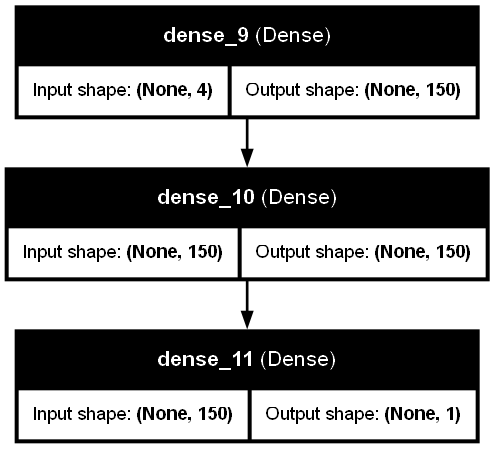

In [26]:
plot_model(keras_regr, 
           to_file='regr_architecture.png', 
           show_shapes=True, 
           show_layer_names=True,
           dpi=96)

Image('regr_architecture.png')

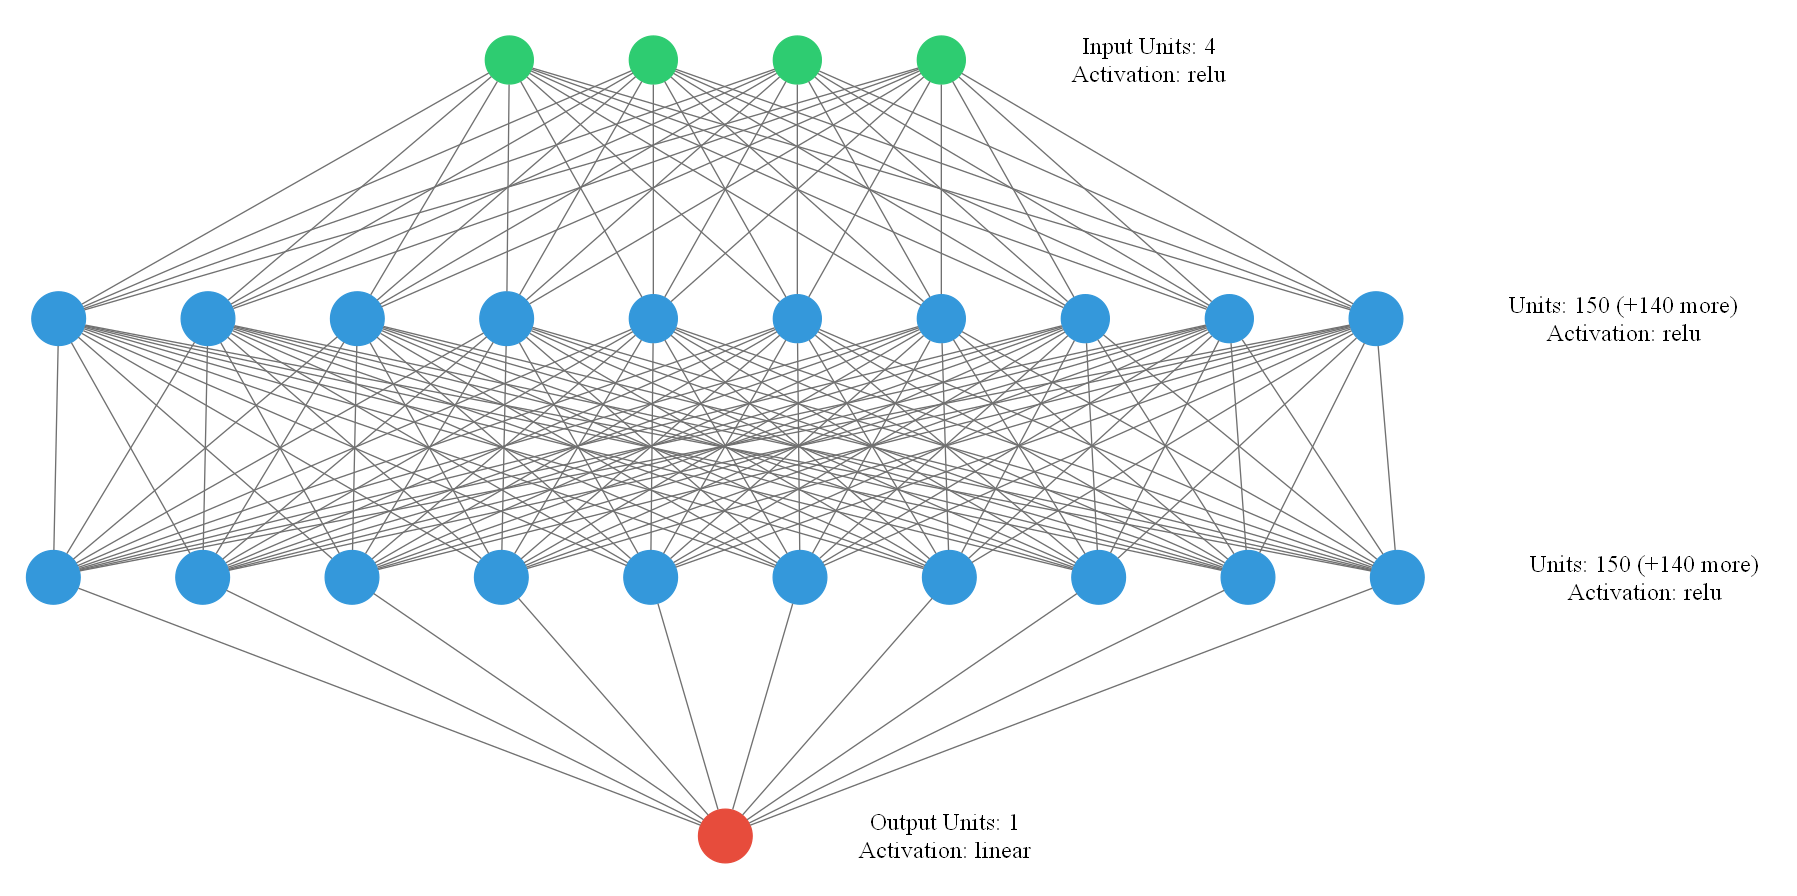

In [30]:
visualizer(keras_regr, 'regr_arch', 'png')
Image('regr_arch.png')

In [17]:
keras_regr.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 150)            │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │        22,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,655 (276.00 KB)

 Trainable params: 23,551 (92.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,104 (184.00 KB)

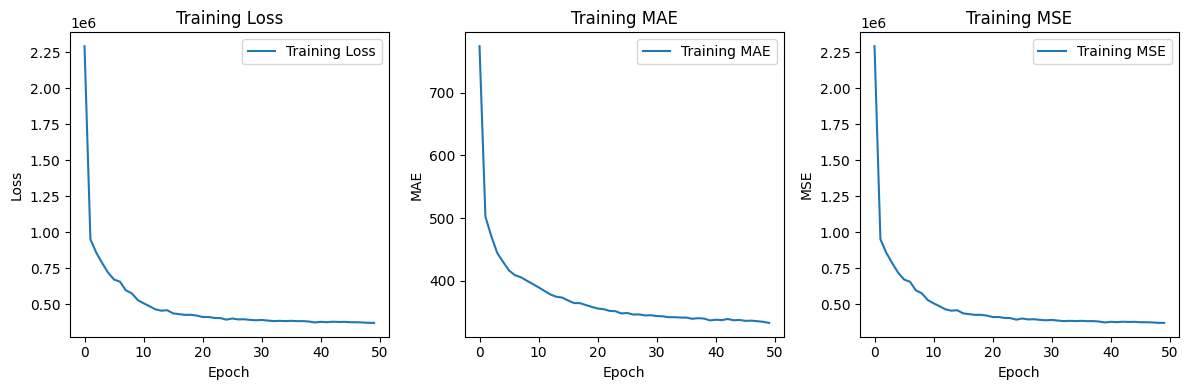

In [27]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.title('Training MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['mse'], label='Training MSE')
plt.title('Training MSE')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Classification

In [13]:
sklearn_clas = MLPClassifier(**{'hidden_layer_sizes': (75,), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.002044563017347889, 'learning_rate_init': 0.002498850933921729, 'batch_size': 256, 'max_iter': 50, 'n_iter_no_change': 19})
sklearn_clas.fit(X_clas, y_clas)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MLPClassifier(alpha=0.002044563017347889, batch_size=256,
              hidden_layer_sizes=(75,), learning_rate_init=0.002498850933921729,
              max_iter=50, n_iter_no_change=19, solver='lbfgs')

In [14]:
print("\nАрхитектура MLPClassifier:")
print(f"Количество слоёв: {sklearn_clas.n_layers_}")
print(f"Количество нейронов в каждом слое: {sklearn_clas.hidden_layer_sizes}")
print(f"Функция активации: {sklearn_clas.activation}")
print(f"Оптимизатор: {sklearn_clas.solver}")
print(f"Размер батча: {sklearn_clas.batch_size}")
print(f"Количество итераций: {sklearn_clas.n_iter_}")


Архитектура MLPClassifier:
Количество слоёв: 3
Количество нейронов в каждом слое: (75,)
Функция активации: relu
Оптимизатор: lbfgs
Размер батча: 256
Количество итераций: 50


In [24]:
keras_clas = build_binary_classification_model_from_config({'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 125, 'optimizer': 'adam', 'lr': 0.00012103000977982242, 'adam_beta_1': 0.8195290083017484, 'adam_beta_2': 0.9549949319258149})
history_clas = keras_clas.fit(X_clas, y_clas, epochs=50, verbose=1)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - f1_metric: 0.1308 - loss: 0.3823
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_metric: 0.6785 - loss: 0.1449
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_metric: 0.7160 - loss: 0.1332
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_metric: 0.7022 - loss: 0.1295
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_metric: 0.6911 - loss: 0.1240
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_metric: 0.7173 - loss: 0.1234
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_metric: 0.7132 - loss: 0.1245
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_metric: 0.7012 - loss: 0.1196
Epoch 9/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - f1_metric: 0.7267 - loss: 0.1185
Epoch 10/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_metric: 0.7163 - loss: 0.1177
Epoch 11/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_metric: 0.7186 - loss: 0.1164
Epoch 12/50
1250/12

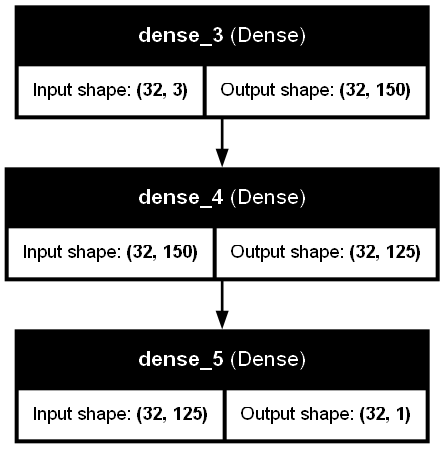

In [23]:
plot_model(keras_clas, 
           to_file='clas_architecture.png', 
           show_shapes=True, 
           show_layer_names=True,
           dpi=96)

Image('clas_architecture.png')

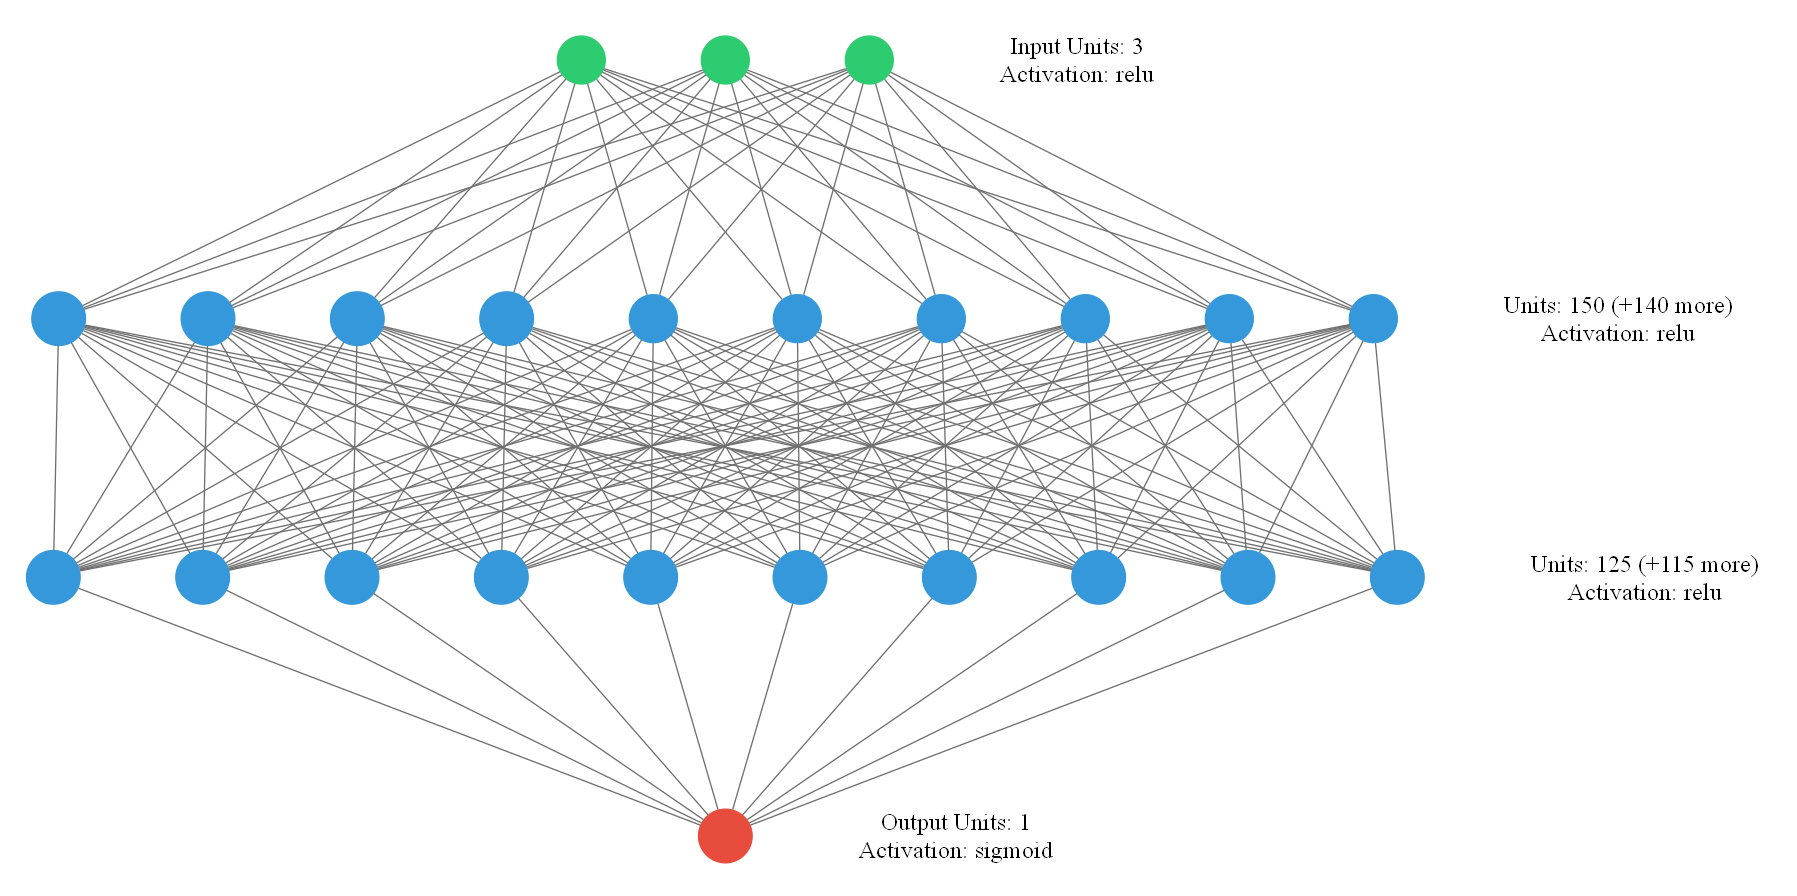

In [31]:
visualizer(keras_clas, 'clas_arch', 'png')
Image('clas_arch.png')

In [30]:
keras_clas.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (32, 150)              │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (32, 125)              │        18,875 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (32, 1)                │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,805 (229.71 KB)

 Trainable params: 19,601 (76.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,204 (153.14 KB)

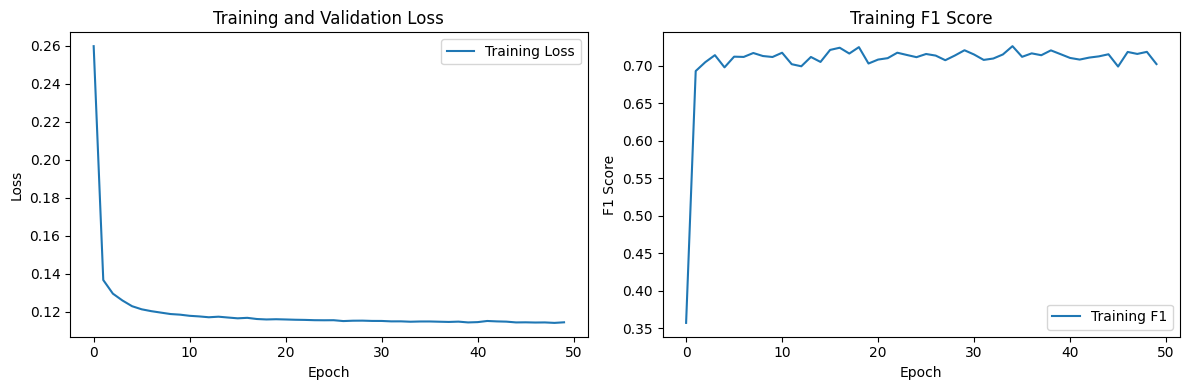

In [35]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_clas.history['loss'], label='Training Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_clas.history['f1_metric'], label='Training F1')
plt.title('Training F1 Score')
plt.ylabel('F1 Score')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

## Classification

# 5. Оценка качества моделей

In [39]:
sklearn_regr = MLPRegressor(**{'activation': 'relu', 'alpha': 0.0002428226815370111, 'batch_size': 64, 'early_stopping': True, 'hidden_layer_sizes': (200, 100), 'learning_rate_init': 0.004195669455125621, 'max_iter': 50, 'n_iter_no_change': 7, 'solver': 'lbfgs'})
sklearn_regr_test = test_regr(sklearn_regr, X_regr, y_regr, 'lbfgs', 50)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

In [28]:
keras_regr = build_model_from_config({'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 150, 'optimizer': 'rmsprop', 'lr': 0.006761133009191603, 'rmsprop_rho': 0.8797626552850855, 'rmsprop_momentum': 0.21112666617269985})
keras_regr_test = test_regr(keras_regr, X_regr, y_regr, 'rmsprop', 50, is_keras=True)

Epoch 1/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4351265.5000 - mae: 973.5741 - mse: 4351265.5000
Epoch 2/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 935371.1875 - mae: 453.3455 - mse: 935371.1875
Epoch 3/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1790552.3750 - mae: 434.2447 - mse: 1790552.3750
Epoch 4/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 928437.6250 - mae: 396.6367 - mse: 928437.6250
Epoch 5/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 758413.4375 - mae: 384.9335 - mse: 758413.4375
Epoch 6/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 628759.2500 - mae: 381.6140 - mse: 628759.2500
Epoch 7/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 669052.6250 - mae: 377.6397 - mse: 669052.6250
Epoch 8/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 845388.9375 - mae: 380.1486 - mse: 845388.9375
Epoch 9/50
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1292537.3750 - mae: 377.9751 - mse: 1292537.3750
Epoch 10/50
1

In [40]:
regr_tests = pd.DataFrame([sklearn_regr_test, keras_regr_test])
regr_tests

,model,optim,epochs,train_R²,train_MSE,train_RMSE,train_MAE,test_R²,test_MSE,test_RMSE,test_MAE
0,MLPRegressor,lbfgs,50,0.97,462107.74048,679.70050,374.79798,0.970,466059.06708,682.57924,374.00758
1,Sequential,rmsprop,50,0.98,330214.70000,574.25756,313.48686,0.978,345457.27502,587.07556,317.64122


In [38]:
sklearn_clas = MLPClassifier(**{'hidden_layer_sizes': (75,), 'activation': 'relu', 'solver': 'lbfgs', 'alpha': 0.002044563017347889, 'learning_rate_init': 0.002498850933921729, 'batch_size': 256, 'max_iter': 50, 'n_iter_no_change': 19})
sklearn_clas_test = test_clas(sklearn_clas, X_clas, y_clas, 'lbfgs', 50)

d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
d:\Python\OmGTU\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

In [34]:
keras_clas = build_binary_classification_model_from_config({'n_layers': 2, 'units_0': 150, 'activation': 'relu', 'units_1': 125, 'optimizer': 'adam', 'lr': 0.00012103000977982242, 'adam_beta_1': 0.8195290083017484, 'adam_beta_2': 0.9549949319258149})
keras_clas_test = test_clas(keras_clas, X_clas, y_clas, 'adam', 50, is_keras=True)

Epoch 1/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_metric: 0.4657 - loss: 0.4163
Epoch 2/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4385 - loss: 0.3230
Epoch 3/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4341 - loss: 0.3093
Epoch 4/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4325 - loss: 0.3041
Epoch 5/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4308 - loss: 0.3013
Epoch 6/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4331 - loss: 0.3036
Epoch 7/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4346 - loss: 0.2971
Epoch 8/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4311 - loss: 0.2981
Epoch 9/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4340 - loss: 0.2951
Epoch 10/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4314 - loss: 0.3015
Epoch 11/50
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_metric: 0.4311 - loss: 0.2954
Epoch 12/50
1826/18

In [41]:
clas_tests = pd.DataFrame([sklearn_clas_test, keras_clas_test])
clas_tests

,model,optim,epochs,train_f1-score,train_accuracy,test_f1-score,test_accuracy
0,MLPClassifier,lbfgs,50,0.848,0.85,0.948,0.946
1,Sequential,adam,50,0.850,0.85,0.948,0.946


# 6. Деплой модели

In [44]:
regr_inputs = np.array([
    [0.25, 2, 4, 4.0],
    [0.40, 5, 3, 4.3],
    [0.30, 3, 6, 4.1],
])

In [59]:
sk = sklearn_regr.predict(regr_inputs)
ker = keras_regr.predict(regr_inputs, verbose=-1)

print('sklearn | keras')
for i in range(3):
    print(f'{round(sk[i])}       {round(ker[i][0])}')

sklearn | keras
225       565
692       721
116       577


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


In [74]:
clas_inputs = np.array([
    [1.2, 0, 1],
    [0.75, 1, 0],
    [0.5, 0, 1],
])

In [75]:
sk = sklearn_clas.predict(clas_inputs)
ker = keras_clas.predict(clas_inputs, verbose=-1)

print('sklearn | keras')
for i in range(3):
    print(f'{round(sk[i])}         {round(ker[i][0])}')

sklearn | keras
0         0
0         0
0         0


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


# 7 Вывод

Результатом лабораторной работы являются 4 нейронные сети архитектуры FCNN. Судя по метрикам оценки качества эти модели практически не отличаются от аналогичных решений, использующих классические алгоритмы ML. 

Выбирая из полученных моделей по метрикам (_RMSE_ и _R²_ для регрессии, _f1-score_ и _accuracy_ для классификации) выбраны "победители" - НС архитектуры FCNN на основе keras и tensorflow.